# Case 5: Maximize the Sharpe ratio, minimize CVaR, keep Tracking Error below a maximun value, comply with the restrictions imposed by UCITS regulations (simplified) while keeping selected asset over a minimun weight and the number of assets within the specified range using gradient descent

## Data load

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import tensorflow as tf

import data_management as dm
from portfolios import Portfolio, Portfolio_Collection
from models import MPOModel
import risk_measures as rm
from utils import (
    mask_greater_than,
    mask_lower_than,
    sparsemax,
)

import warnings

warnings.filterwarnings("ignore")
tf.keras.backend.set_floatx("float32")

### Index and components

In [2]:
data, data_idx = dm.DataManagement.get_data(
    asset_price_path="../data/data_comp_SP500.csv",
    idx_price_path="../data/data_idx_SP500.csv",
)

### Train/Test split

In [3]:
# Desired dates.
ds_start_date = "2010-07-15"
ds_end_date = "2024-10-18"
train_start_date = "2019-12-31"
train_end_date = "2020-12-31"
test_start_date = "2021-01-01"
test_end_date = "2021-06-30"

# Sync dataframes
data, data_idx = dm.DataManagement.sync_dataframes(data, data_idx)
data_log_ret = dm.DataManagement.convert_prices_to_log_returns(data)

# Compute logarithmic returns.
data_idx_log_ret = dm.DataManagement.convert_prices_to_log_returns(data_idx)

# Filter dates.
data_log_ret = data_log_ret.loc[ds_start_date:ds_end_date, :]
data_idx_log_ret = data_idx_log_ret.loc[ds_start_date:ds_end_date, :]

# Train and test datasets.
X_train, y_train, X_test, y_test = dm.DataManagement.train_test_split_by_date(
    X=data_log_ret,
    y=data_idx_log_ret,
    train_start_date=train_start_date,
    train_end_date=train_end_date,
    test_start_date=test_start_date,
    test_end_date=test_end_date,
    train_freq="D",
)

In [4]:
risk_free_return = np.float32(0.08 / 252)
# risk_free_return = 0.0

## Portfolio optimization using gradient descent

In [5]:
def custom_loss_function(
    l_sharpe=0.0,
    l_cvar=0.0,
    l_te=0.0,
    l_010=0.0,
    l_005040=0.0,
    l_min_weight=0.0,
    l_num_assets=0.0,
    rf=0.0,
    max_tracking_error=0.004,
    min_weight=0.005,
    max_assets=30,
    min_assets=20,
):
    def loss_function(
        assets_rets,  # Assets returns
        w,  # Portfolio weights
        idx=None,  # Index returns
    ):
        # We want the lambdas to be positive.
        lambda_sharpe = tf.nn.relu(l_sharpe)
        lambda_cvar = tf.nn.relu(l_cvar)
        lambda_te = tf.nn.relu(l_te)
        lambda_010 = tf.nn.relu(l_010)
        lambda_005040 = tf.nn.relu(l_005040)
        lambda_min_weight = tf.nn.relu(l_min_weight)
        lambda_num_assets = tf.nn.relu(l_num_assets)

        # Portfolio returns.
        p_rets = tf.matmul(assets_rets, w)

        ###############
        # Sharpe Ratio
        ###############
        sharpe = rm.RiskMeasures.Sharpe_Ratio_tf(x=p_rets, r_f=rf)

        ###############
        # CVaR
        ###############
        # Calculate CVaR at 95%.
        # This function gives the result in positive.
        cvar = rm.RiskMeasures.CVaR_tf(x=p_rets, alpha=0.05)

        ###############
        # Minimum weights
        ###############
        mask = mask_lower_than(w, min_weight)
        weights_below_min = tf.multiply(w, mask)
        penalty_min_weight = tf.reduce_sum(weights_below_min)

        ###############
        # TRACKING ERROR
        ###############
        # Calculate Tracking Error (standard deviation of the difference between portfolio returns and index returns).
        te = rm.RiskMeasures.TrackingError_tf(x=p_rets, y=idx)
        penalty_te = tf.nn.relu(te - max_tracking_error)

        ###############
        # UCITS
        ###############

        ###############
        # < 10% WEIGHT
        ###############
        # Penalty term for weight constraints.
        # Penalizes weights greater than 0.10
        penalty_010 = tf.reduce_sum(tf.nn.relu(w - 0.10))

        ###############
        # > 5% WEIGHT => SUM < 40%
        ###############
        # Penalty term for weight constraints.
        # Penalizes sum of weights exceeding 0.40
        mask = mask_greater_than(w, 0.05)
        weights_over_005 = tf.multiply(w, mask)
        penalty_005040 = tf.nn.relu(tf.reduce_sum(weights_over_005) - 0.40)

        ###############
        # Maximum/minimum number of assets
        ###############
        mask = mask_greater_than(w, 0.0)
        penalty_num_assets = tf.nn.relu((min_assets - tf.reduce_sum(mask)) * (max_assets - tf.reduce_sum(mask)))

        # Update the loss.
        loss = (
            lambda_sharpe * (-sharpe)
            + lambda_cvar * (cvar)
            + lambda_te * penalty_te
            + lambda_010 * penalty_010
            + lambda_005040 * penalty_005040
            + lambda_min_weight * penalty_min_weight
            + lambda_num_assets * penalty_num_assets
        )

        return {
            "loss": loss,  # Only for training, without converting to numpy.
            "weights": w.numpy(),
            "metrics": {
                "loss": loss.numpy(),
                "loss_sharpe": (lambda_sharpe * (-sharpe)).numpy(),
                "loss_cvar": (lambda_cvar * cvar).numpy(),
                "loss_te": (lambda_te * penalty_te).numpy(),
                "loss_010": (lambda_010 * penalty_010).numpy(),
                "loss_005040": (lambda_005040 * penalty_005040).numpy(),
                "loss_min_weight": (lambda_min_weight * penalty_min_weight).numpy(),
                "loss_num_assets": (lambda_num_assets * penalty_num_assets).numpy(),
            },
        }

    return loss_function

In [6]:
def custom_get_best_weights():
    def get_best_weights(history: list) -> np.ndarray:
        weights = pd.DataFrame([h["weights"].squeeze() for h in history])
        metrics = pd.DataFrame([h["metrics"] for h in history])
        idx_min_loss = metrics["loss"].idxmin()
        selected_weights = weights.loc[idx_min_loss].to_numpy()
        return selected_weights.squeeze()

    return get_best_weights

In [7]:
def custom_weights_function():
    return sparsemax

In [8]:
num_assets = X_train.shape[1]
mw = 0.01
max_a = 30
min_a = 20
loss_function = custom_loss_function(
    l_cvar=1.0 / 0.01,
    l_sharpe=1.0 / 0.1,
    l_te=4.0 / 0.001,
    l_010=1.0 / 0.1,
    l_005040=1.0 / 0.1,
    l_min_weight=1.0 / 0.1,
    l_num_assets=1.0 / 100000,
    rf=risk_free_return,
    max_tracking_error=0.004,
    min_weight=mw,
    max_assets=max_a,
    min_assets=min_a,
)
weights_function = custom_weights_function()
get_best_weights_function = custom_get_best_weights()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)


mpo = MPOModel(
    num_assets=num_assets,
    loss_function=loss_function,
    weights_function=weights_function,
    get_best_weights_function=get_best_weights_function,
    optimizer=optimizer,
    random_weight_init=False,
)

In [9]:
history = mpo.fit(x=X_train, idx=y_train, epochs=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:38<00:00, 10.11it/s]


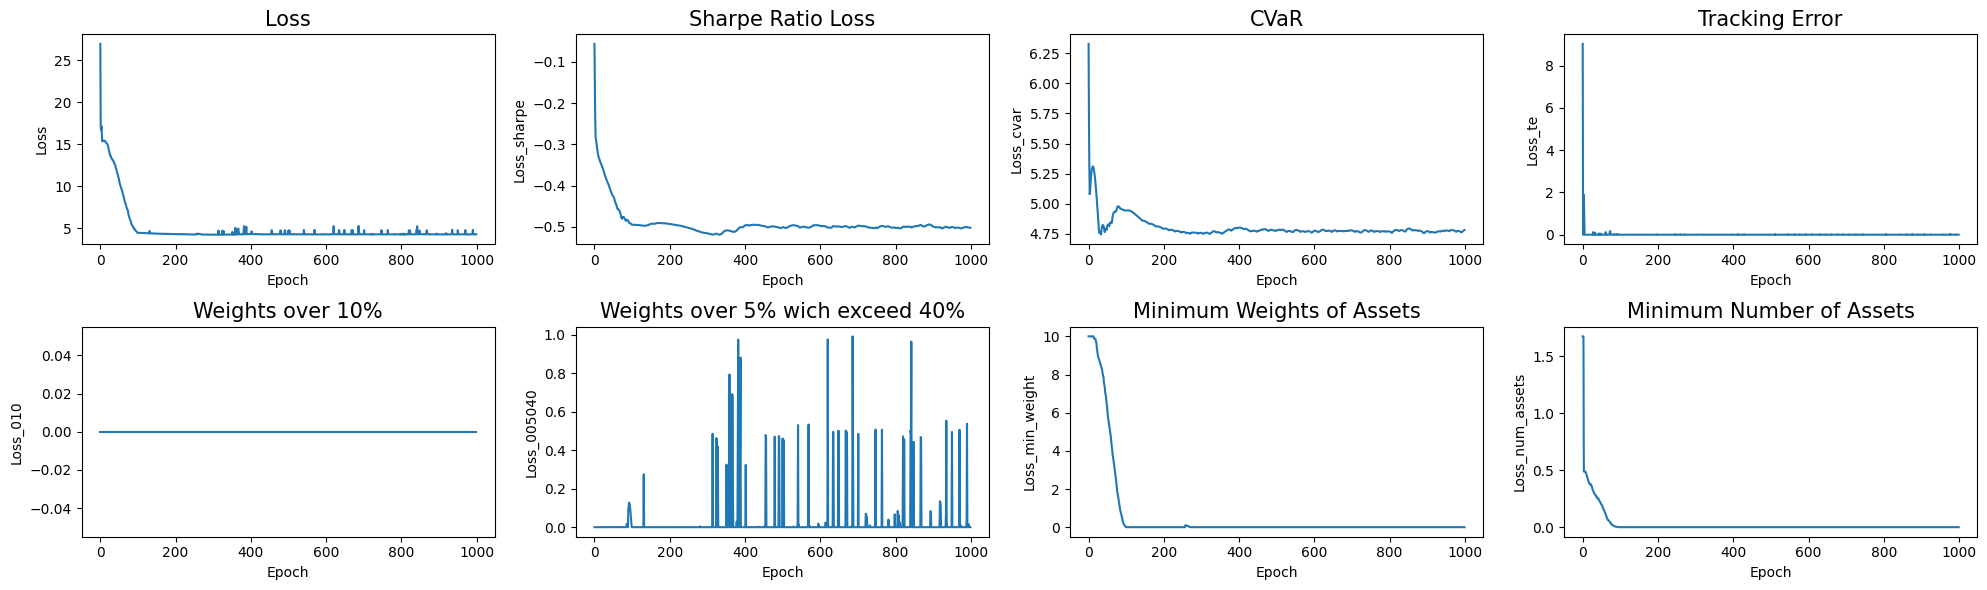

In [10]:
mpo.plot_all_training_metrics(
    save_as="../results/Case_05/MaxSharpe_MinCVaR_Tracking_MinWeight_AssetRange_UCITS_gd_optimizer_training_metrics.png",
    titles={
        "loss": "Loss",
        "loss_sharpe": "Sharpe Ratio Loss",
        "loss_cvar": "CVaR",
        "loss_te": "Tracking Error",
        "loss_010": "Weights over 10%",
        "loss_005040": "Weights over 5% wich exceed 40%",
        "loss_min_weight": "Minimum Weights of Assets",
        "loss_num_assets": "Minimum Number of Assets",
    },
)

In [11]:
gd_portfolio_name = "Case 5 - GD"
gd_portfolio = Portfolio(
    name=gd_portfolio_name,
    asset_weights=mpo.get_best_weights(),
    asset_names=X_train.columns,
)

Sum of weights > 5%: 0.39662086963653564
Number of assets in portfolio: 23


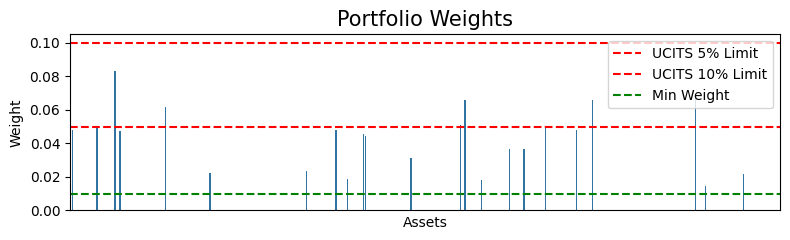

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & A & AAPL & ABT & ACGL & ACN & ADBE & ADI & ADM & ADP & ADSK & AEE & AEP & AES & AFL & AIG & AIZ & AJG & AKAM & ALB & ALGN & ALL & AMAT & AMD & AME & AMGN & AMP & AMT & AMZN & ANSS & AON & AOS & APA & APD & APH & ARE & ATO & AVB & AVGO & AVY & AWK & AXON & AXP & AZO & BA & BAC & BALL & BAX & BBY & BDX & BEN & BG & BIIB & BK & BKNG & BKR & BLDR & BLK & BMY & BR & BRO & BSX & BWA & BX & BXP & C & CAG & CAH & CAT & CB & CBOE & CBRE & CCI & CCL & CDNS & CE & CF & CHD & CHRW & CHTR & CI & CINF & CL & CLX & CMCSA & CME & CMG & CMI & CMS

In [12]:
gd_portfolio.plot_weights(
    plot_ucits_limits=True,
    plot_min_weight=True,
    min_weight=mw,
    skip_zero_weights=False,
    save_as="../results/Case_05/MaxSharpe_MinCVaR_Tracking_MinWeight_AssetRange_UCITS_gd_optimizer_portfolio_weights.png",
    figsize=(8, 2.5),
)

Sum of weights > 5%: 0.39662086963653564
Number of assets in portfolio: 23


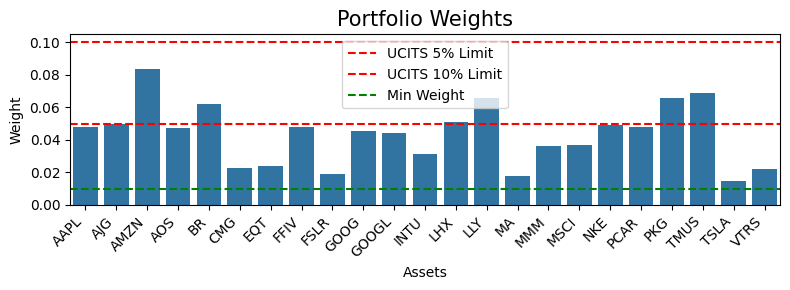

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & AAPL & AJG & AMZN & AOS & BR & CMG & EQT & FFIV & FSLR & GOOG & GOOGL & INTU & LHX & LLY & MA & MMM & MSCI & NKE & PCAR & PKG & TMUS & TSLA & VTRS \\
\midrule
Weight & 0.047957 & 0.049757 & 0.083435 & 0.047238 & 0.061812 & 0.022577 & 0.023622 & 0.047738 & 0.018974 & 0.045624 & 0.044092 & 0.031221 & 0.051022 & 0.065897 & 0.017926 & 0.036441 & 0.036586 & 0.049391 & 0.047669 & 0.065826 & 0.068629 & 0.014590 & 0.021980 \\
\bottomrule
\end{tabular}



In [13]:
gd_portfolio.plot_weights(
    plot_ucits_limits=True,
    plot_min_weight=True,
    min_weight=mw,
    skip_zero_weights=True,
    save_as="../results/Case_05/MaxSharpe_MinCVaR_Tracking_MinWeight_AssetRange_UCITS_gd_optimizer_portfolio_weights_no_zeros.png",
    figsize=(8, 3),
)

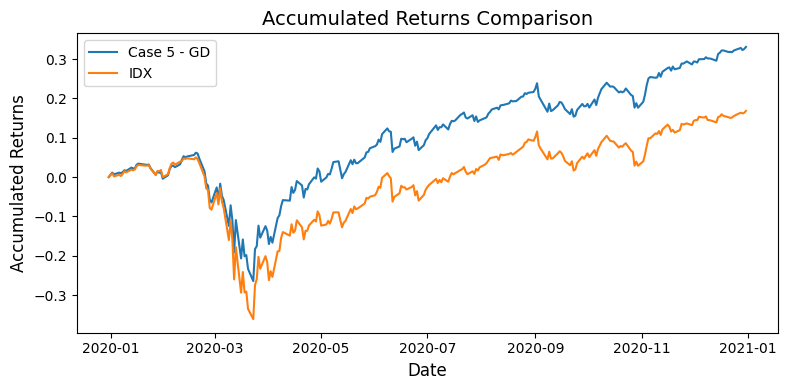

                  Std    Sharpe  TrackingError       VaR      CVaR  \
Case 5 - GD  0.019284  0.051612       0.003996  0.031112  0.047519   
IDX          0.021113  0.016771       0.000000  0.033728  0.056878   

             WeightsOver10pct  WeightsOver5pct  
Case 5 - GD               0.0         0.396621  
IDX                       NaN              NaN  


In [16]:
# Nos permite almacenar y comparar las distintas carteras.
portfolios = Portfolio_Collection(portfolio_names=[], portfolio_weights=[], asset_names=X_train.columns)

portfolios.replace_or_add_portfolio(
    name=gd_portfolio.name,
    new_portfolio=gd_portfolio,
)

portfolios.plot_cumulative_returns(
    asset_returns=X_train,
    idx_returns=y_train,
    portfolio_names=[
        gd_portfolio.name,
    ],
    plot_idx=True,
    comparable_returns=[],
    rf=risk_free_return,
    zero_start=True,
    save_as="../results/Case_05/MaxSharpe_MinCVaR_Tracking_MinWeight_AssetRange_UCITS_gd_optimizer_portfolio_acum_returns.png",
    figsize=(8, 4),
)